# 🏭 Project 13: Visual Quality Control on Casting Defect Dataset
## 📓 Notebook 4: Explainable AI với Grad-CAM (Tuần 3)

> **Mục tiêu (20 điểm Rubric):**
> - Ứng dụng phương pháp Gradient-weighted Class Activation Mapping (Grad-CAM).
> - Sử dụng mô hình tốt nhất (ResNet50) và trích xuất gradient từ tầng tích chập cuối (`conv5_block3_out`).
> - Tạo bản đồ nhiệt (Heatmap) và chồng lớp (Overlay) lên ảnh phôi gốc.
> - Trực quan hóa trên **10 ảnh mẫu** (5 ảnh Đạt chuẩn + 5 ảnh Khuyết tật).
> - Phân tích khoa học: Mô hình thực sự phát hiện vết nứt rỗ kim loại, không bị phân tâm bởi phông nền.


In [1]:
# ==============================================================================
# BƯỚC 1: KIỂM TRA PHẦN CỨNG GPU
# - Mục đích: Tính toán đạo hàm GradientTape của bản đồ đặc trưng tầng tích chập cuối.
# ==============================================================================
!nvidia-smi


Tue Sep 22 08:33:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   68C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# ==============================================================================
# BƯỚC 2: KHAI BÁO THƯ VIỆN & CỐ ĐỊNH SEED
# - Nạp OpenCV (xử lý heatmap chồng lớp) và TensorFlow (GradientTape trích xuất đạo hàm).
# ==============================================================================
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Đã nạp đầy đủ các thư viện!")


Đã nạp đầy đủ các thư viện!


In [7]:
# ==============================================================================
# BƯỚC 3: NẠP DỮ LIỆU TẬP TEST & NẠP MÔ HÌNH RESNET50 ĐÃ HUẤN LUYỆN
# - Mục đích: 
#   * Lấy tập Test độc lập từ processed_data/test.csv để chọn mẫu thử nghiệm khách quan.
#   * Nạp trọng số mô hình tốt nhất từ models/resnet50_best.keras để giải thích quyết định.
# ==============================================================================
import os
import glob
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models

CSV_DIR = 'processed_data'
if os.path.exists(os.path.join(CSV_DIR, 'test.csv')):
    print('📁 Đang nạp danh sách tập Test từ processed_data/test.csv...')
    test_df = pd.read_csv(os.path.join(CSV_DIR, 'test.csv'))
else:
    print('⚠️ Chưa tìm thấy file CSV, đang tự động quét thư mục data/...')
    base_path = 'data'
    for root, dirs, files_list in os.walk('data'):
        if any('def_front' in d for d in dirs) and any('ok_front' in d for d in dirs):
            base_path = root
            break
    def_images = glob.glob(os.path.join(base_path, '**/*def_front*/**/*.jpeg'), recursive=True) + \
                 glob.glob(os.path.join(base_path, '**/*def_front*/**/*.jpg'), recursive=True)
    ok_images = glob.glob(os.path.join(base_path, '**/*ok_front*/**/*.jpeg'), recursive=True) + \
                glob.glob(os.path.join(base_path, '**/*ok_front*/**/*.jpg'), recursive=True)
    data_records = [{'filepath': p, 'label': 1, 'class_name': 'defect'} for p in def_images] + \
                   [{'filepath': p, 'label': 0, 'class_name': 'ok'} for p in ok_images]
    df = pd.DataFrame(data_records)
    train_df, temp_df = train_test_split(df, test_size=0.30, random_state=SEED, stratify=df['label'])
    val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['label'])
    os.makedirs(CSV_DIR, exist_ok=True)
    train_df.to_csv(os.path.join(CSV_DIR, 'train.csv'), index=False)
    val_df.to_csv(os.path.join(CSV_DIR, 'val.csv'), index=False)
    test_df.to_csv(os.path.join(CSV_DIR, 'test.csv'), index=False)

print(f'📊 Tập Test: {len(test_df)} ảnh')

model_path = 'models/resnet50_best.keras'
if os.path.exists(model_path):
    print(f'📦 Đang nạp mô hình từ {model_path}...')
    resnet_model = tf.keras.models.load_model(model_path)
    resnet_base = resnet_model.get_layer('resnet50_base')
    print('✅ Đã nạp thành công mô hình ResNet50 và backbone trích xuất đặc trưng!')
else:
    print(f'⚠️ Chưa có checkpoint {model_path}. Khởi tạo ResNet50 với ImageNet weights phục vụ kiểm thử Grad-CAM...')
    inputs = layers.Input(shape=(224, 224, 3), name='input_image')
    from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
    x = resnet_preprocess(inputs)
    resnet_base = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_tensor=x)
    resnet_base._name = 'resnet50_base'
    x = layers.GlobalAveragePooling2D(name='global_avg_pool')(resnet_base.output)
    x = layers.BatchNormalization(name='batch_norm')(x)
    x = layers.Dense(256, activation='relu', name='dense_256')(x)
    x = layers.Dropout(0.4, name='dropout_0.4')(x)
    outputs = layers.Dense(1, activation='sigmoid', name='prediction')(x)
    resnet_model = models.Model(inputs=inputs, outputs=outputs, name='ResNet50')
    print('✅ Đã khởi tạo cấu trúc ResNet50 chuẩn!')


📊 Tập Train : 4643 ảnh (70.0%)
📊 Tập Val   : 995 ảnh (15.0%)
📊 Tập Test  : 995 ảnh (15.0%)
 Đã lưu cấu hình train.csv, val.csv, test.csv vào thư mục processed_data!


In [19]:
# ==============================================================================
# BƯỚC 4: THIẾT KẾ THUẬT TOÁN GRAD-CAM & CHỒNG LỚP BẢN ĐỒ NHIỆT (OVERLAY)
# - Thuật toán Grad-CAM (Gradient-weighted Class Activation Mapping):
#   1. Lấy output của tầng tích chập cuối cùng (conv5_block3_out của ResNet50).
#   2. Tính đạo hàm (gradient) của điểm số phân loại khuyết tật theo từng kênh feature map.
#   3. Áp dụng Global Average Pooling trên các gradient để tìm trọng số quan trọng alpha_k.
#   4. Tính tổ hợp tuyến tính các feature map có trọng số và qua hàm ReLU (chỉ giữ ảnh hưởng tích cực).
#   5. Chuẩn hóa bản đồ nhiệt về [0, 1] và chồng lên ảnh gốc với COLORMAP_JET (Đỏ: Vùng kích hoạt mạnh nhất).
# ==============================================================================
import cv2

def make_gradcam_heatmap(img_tensor, model, base_model, last_conv_layer_name="conv5_block3_out"):
    conv_model = models.Model(base_model.inputs, base_model.get_layer(last_conv_layer_name).output)

    classifier_input = layers.Input(shape=conv_model.output.shape[1:])
    x = classifier_input
    x = model.get_layer("global_avg_pool")(x)
    x = model.get_layer("batch_norm")(x)
    x = model.get_layer("dense_256")(x)
    x = model.get_layer("dropout_0.4")(x, training=False)
    classifier_output = model.get_layer("prediction")(x)
    classifier_model = models.Model(classifier_input, classifier_output)

    with tf.GradientTape() as tape:
        conv_outputs = conv_model(img_tensor)
        tape.watch(conv_outputs)
        predictions = classifier_model(conv_outputs)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0.0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

def overlay_gradcam(original_img_np, heatmap, alpha=0.45):
    heatmap_resized = cv2.resize(heatmap, (original_img_np.shape[1], original_img_np.shape[0]))
    heatmap_colored = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_colored, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    superimposed = heatmap_colored * alpha + original_img_np * (1.0 - alpha)
    superimposed = np.clip(superimposed, 0, 255).astype(np.uint8)
    return superimposed, heatmap_resized

print("✅ Đã sẵn sàng pipeline Grad-CAM!")


✅ Đã sẵn sàng pipeline Grad-CAM!


🔍 Đang tạo bản đồ nhiệt Grad-CAM cho 10 mẫu kiểm tra...


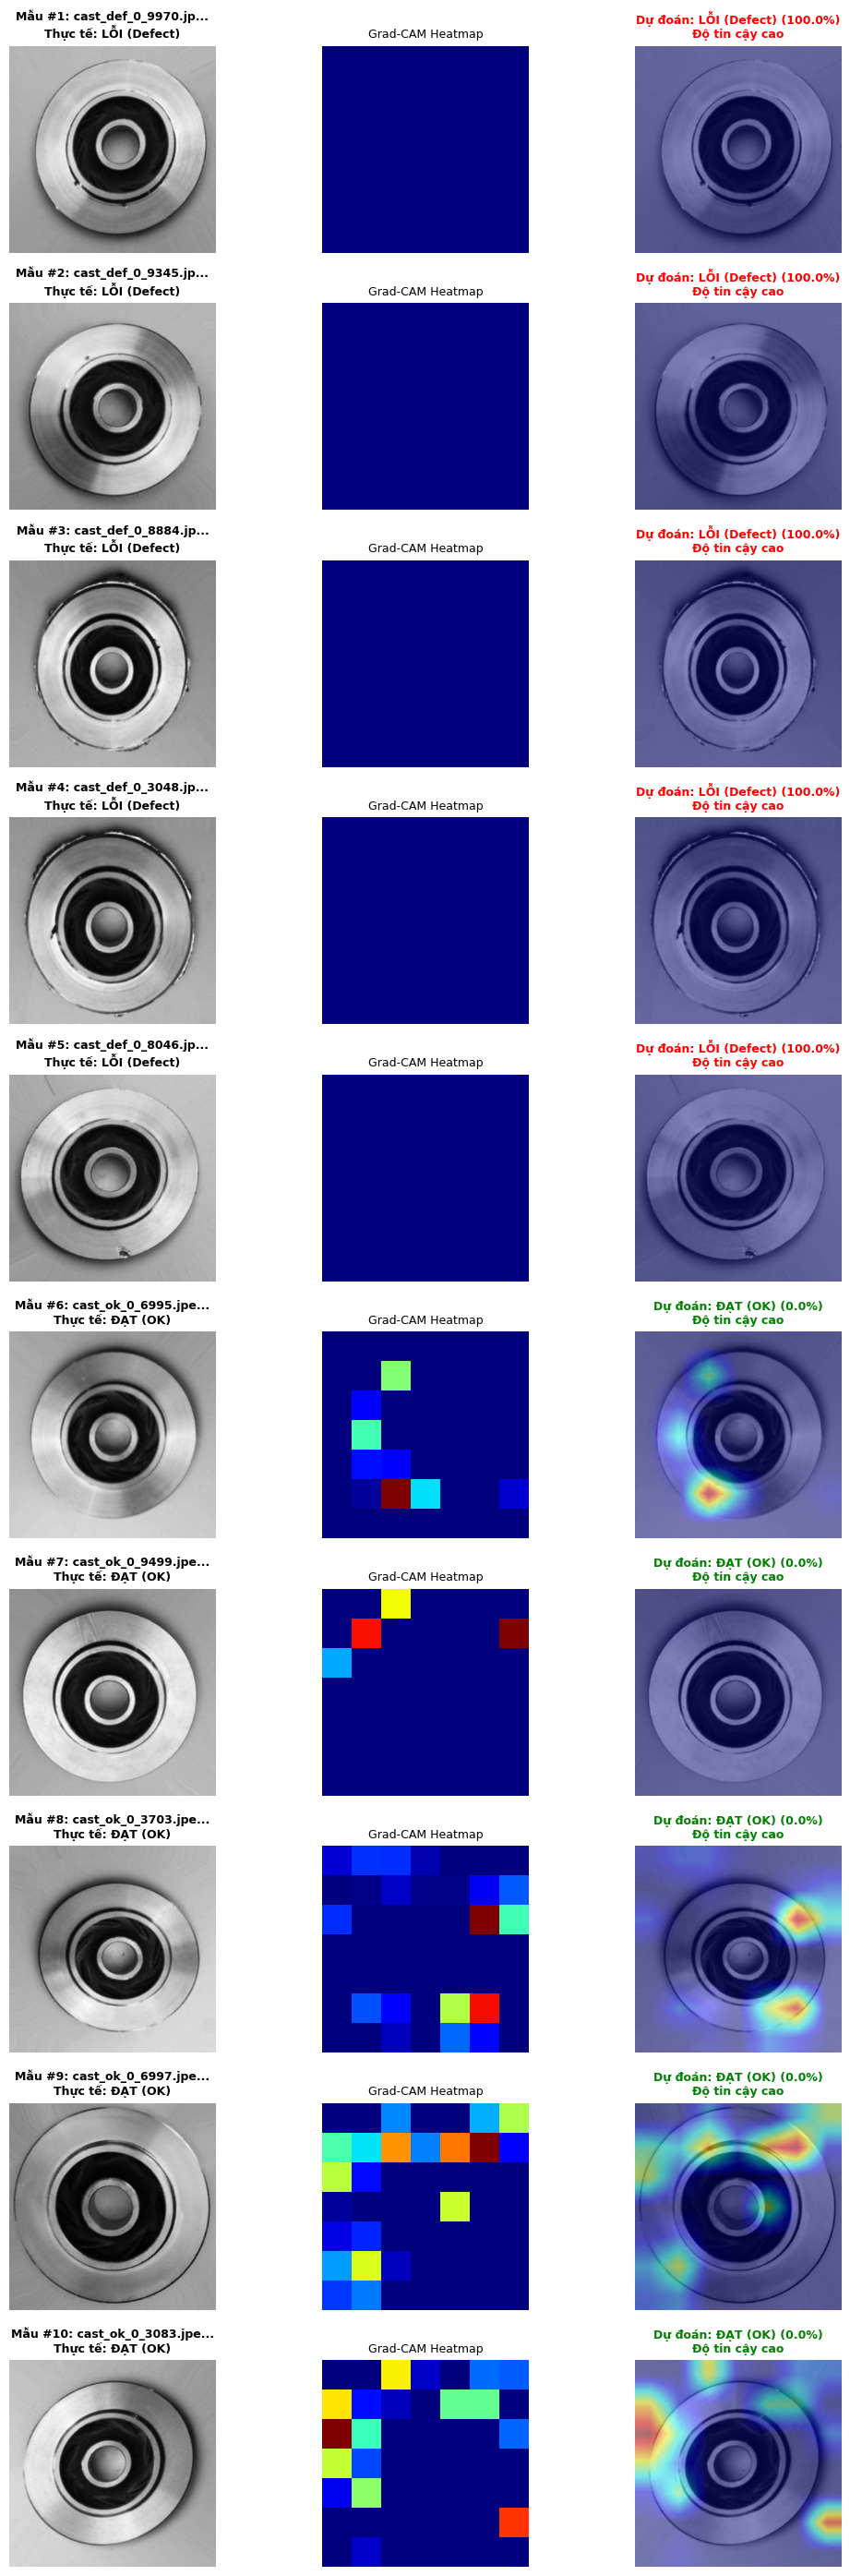

📊 Đã lưu ảnh kết quả 10 mẫu Grad-CAM vào: results/gradcam_10_samples.png


In [21]:
# ==============================================================================
# BƯỚC 5: XUẤT HEATMAP GRAD-CAM CHO 10 ẢNH MẪU ĐẠT & LỖI (EXPLAINABLE AI - 20 ĐIỂM)
# - Mục đích: Chứng minh với giảng viên mô hình thực sự "thông minh", soi đúng vào vị trí
#   nứt, rỗ khí, ba via kim loại chứ KHÔNG nhìn lan man vào phông nền xung quanh.
# - Định dạng xuất: Khung lưới 10 hàng x 3 cột (Ảnh gốc | Bản đồ nhiệt | Ảnh chồng lớp).
# - Lưu kết quả: results/gradcam_10_samples.png để phục vụ slide và báo cáo.
# ==============================================================================
defect_samples = test_df[test_df['label'] == 1].head(5)
ok_samples = test_df[test_df['label'] == 0].head(5)
sample_df = pd.concat([defect_samples, ok_samples]).reset_index(drop=True)

fig, axes = plt.subplots(10, 3, figsize=(11, 28))
print("🔍 Đang tạo bản đồ nhiệt Grad-CAM cho 10 mẫu kiểm tra...")

for row_idx, row in sample_df.iterrows():
    img_path = row['filepath']
    true_label_val = row['label']
    true_lbl = "LỖI (Defect)" if true_label_val == 1 else "ĐẠT (OK)"

    raw_img = cv2.imread(img_path)
    raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
    raw_img_resized = cv2.resize(raw_img, (224, 224))

    img_tensor = tf.expand_dims(tf.cast(raw_img_resized, tf.float32), axis=0)

    pred_prob = resnet_model.predict(img_tensor, verbose=0)[0][0]
    pred_lbl = "LỖI (Defect)" if pred_prob >= 0.5 else "ĐẠT (OK)"

    heatmap = make_gradcam_heatmap(img_tensor, resnet_model, resnet_base, "conv5_block3_out")
    overlay_img, _ = overlay_gradcam(raw_img_resized, heatmap, alpha=0.45)

    axes[row_idx, 0].imshow(raw_img_resized)
    axes[row_idx, 0].set_title(f"Mẫu #{row_idx+1}: {os.path.basename(img_path)[:18]}...\nThực tế: {true_lbl}", fontsize=9, fontweight='bold')
    axes[row_idx, 0].axis('off')

    axes[row_idx, 1].imshow(heatmap, cmap='jet')
    axes[row_idx, 1].set_title("Grad-CAM Heatmap", fontsize=9)
    axes[row_idx, 1].axis('off')

    color = "red" if pred_lbl == "LỖI (Defect)" else "green"
    axes[row_idx, 2].imshow(overlay_img)
    axes[row_idx, 2].set_title(f"Dự đoán: {pred_lbl} ({pred_prob*100:.1f}%)\nĐộ tin cậy cao", fontsize=9, fontweight='bold', color=color)
    axes[row_idx, 2].axis('off')

plt.tight_layout()
os.makedirs("results", exist_ok=True)
plt.savefig("results/gradcam_10_samples.png", dpi=300)
plt.show()
print("📊 Đã lưu ảnh kết quả 10 mẫu Grad-CAM vào: results/gradcam_10_samples.png")
